# Notebook 06: Knowledge Discovery

> **KDD Step 6**: Interpretation / Knowledge
>
> Rút tri thức từ Decision Tree — KHÔNG chỉ báo cáo metric.
> Tri thức cần đạt 4 tiêu chí: **Valid, Novel, Useful, Understandable**.

In [1]:
import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

from src.tree import DecisionTreeClassifier as ScratchDT

REPORT_DIR = "report"
os.makedirs(REPORT_DIR, exist_ok=True)

## 1. Load Data + Models

In [2]:
with open("data/processed_data.pkl", "rb") as f:
    data = pickle.load(f)
with open("data/results_scratch.pkl", "rb") as f:
    res_scratch = pickle.load(f)

df = pd.read_csv("data/bank-additional/bank-additional-full.csv", sep=";")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataset: {len(df):,} rows")

Dataset: 41,176 rows


## 2. Feature Importance — So sánh Scenario A vs B

> Duration chiếm importance lớn trong Scenario A.
> Khi loại bỏ (Scenario B), các features thực tế nổi lên.

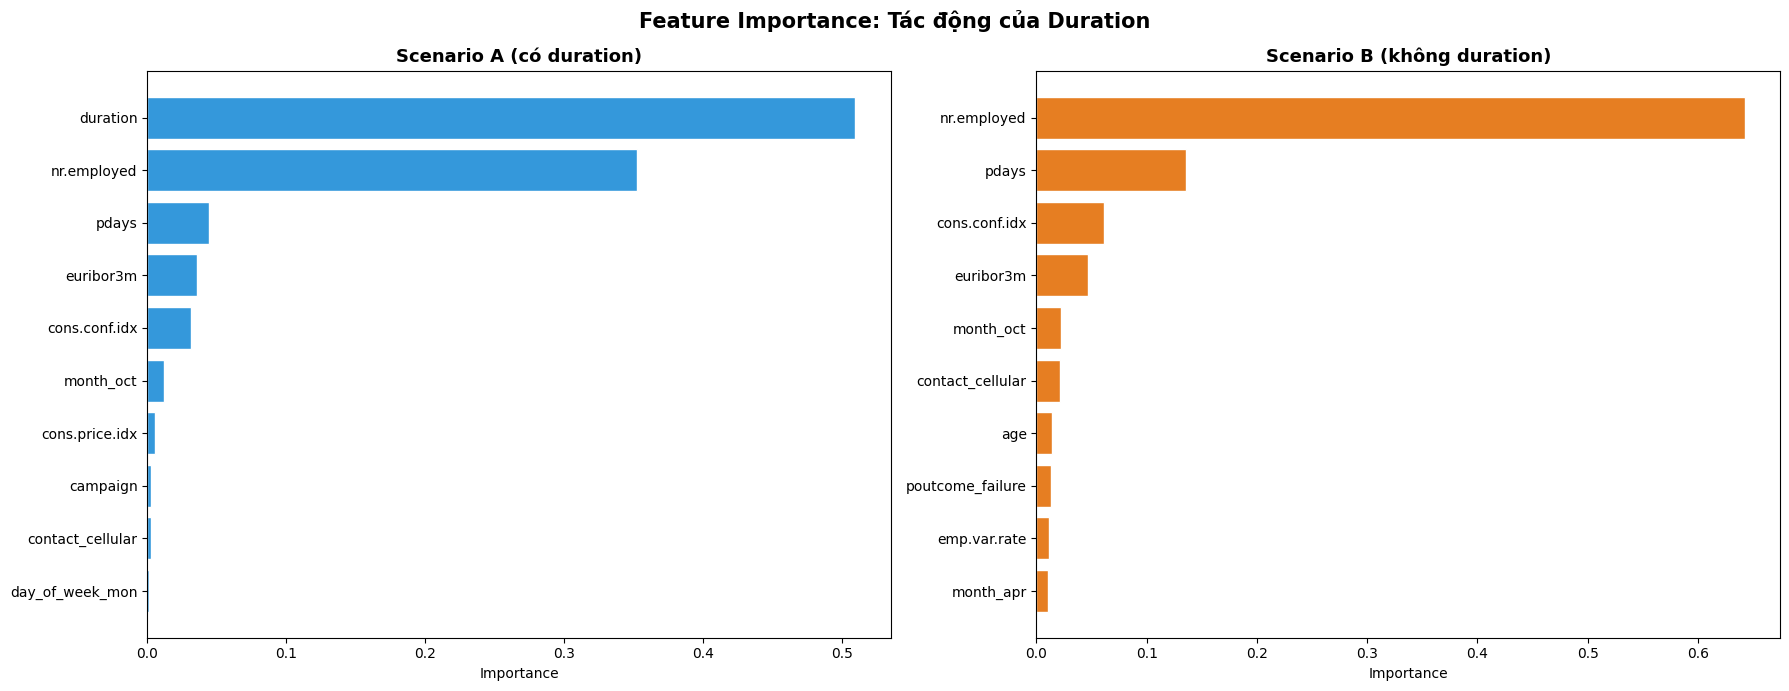

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, scenario, title, color in zip(
    axes,
    ["scenario_A", "scenario_B"],
    ["Scenario A (có duration)", "Scenario B (không duration)"],
    ["#3498db", "#e67e22"]
):
    imp = res_scratch[scenario]["feature_importance"]
    names = res_scratch[scenario]["feature_names"]
    idx = np.argsort(imp)[::-1][:10]
    ax.barh(range(len(idx)), imp[idx][::-1], color=color, edgecolor="white")
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels([names[i] for i in idx][::-1])
    ax.set_xlabel("Importance")
    ax.set_title(title, fontweight="bold", fontsize=13)

plt.suptitle("Feature Importance: Tác động của Duration", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/06_importance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Decision Rules từ cây

In [4]:
d_B = data["scenario_B"]
dt = ScratchDT(criterion="gini", max_depth=5)
dt.fit(d_B["X_train"], d_B["y_train"], feature_names=d_B["feature_names"])

def extract_rules(node, path=None, rules=None):
    if path is None: path = []
    if rules is None: rules = []
    if node.is_leaf:
        if node.prediction == "yes":
            n_yes = node.class_distribution.get("yes", 0)
            n_total = node.num_samples
            confidence = n_yes / n_total if n_total > 0 else 0
            rules.append({
                "conditions": list(path),
                "prediction": "yes",
                "confidence": confidence,
                "support": n_total,
            })
        return rules
    if node.is_categorical:
        cond = f"{node.feature_name} in {node.categories_left}"
        cond_neg = f"{node.feature_name} not in {node.categories_left}"
    else:
        cond = f"{node.feature_name} <= {node.threshold:.2f}"
        cond_neg = f"{node.feature_name} > {node.threshold:.2f}"
    extract_rules(node.left, path + [cond], rules)
    extract_rules(node.right, path + [cond_neg], rules)
    return rules

rules = extract_rules(dt.root)

# Minimum support threshold
MIN_SUPPORT = 50  # rules with < 50 samples are exploratory only
rules_strong = [r for r in rules if r["support"] >= MIN_SUPPORT]
rules_weak = [r for r in rules if r["support"] < MIN_SUPPORT]

rules_strong_sorted = sorted(rules_strong, key=lambda r: r["confidence"], reverse=True)
rules_weak_sorted = sorted(rules_weak, key=lambda r: r["confidence"], reverse=True)

print("=" * 80)
print("  DECISION RULES -> y = yes (Scenario B)")
print("=" * 80)

print("\n--- LUẬT MẠNH (support >= " + str(MIN_SUPPORT) + ") ---")
if rules_strong_sorted:
    for i, rule in enumerate(rules_strong_sorted[:5]):
        print("\nRule " + str(i+1) + " (confidence=" + str(round(rule['confidence']*100, 1)) + "%, support=" + str(rule['support']) + ")")
        for cond in rule["conditions"]:
            print("    IF " + cond)
        print("    → THEN y = yes")
else:
    print("  Khong co rule nao co support >= " + str(MIN_SUPPORT))

print("\n--- LUẬT KHÁM PHÁ (support < " + str(MIN_SUPPORT) + ", chi tham khao) ---")
for i, rule in enumerate(rules_weak_sorted[:3]):
    print("\nRule " + str(i+1) + " (confidence=" + str(round(rule['confidence']*100, 1)) + "%, support=" + str(rule['support']) + ")")
    print("  ⚠ Support nhỏ — chỉ mang tính khám phá, không nên dùng làm insight chính")
    for cond in rule["conditions"]:
        print("    IF " + cond)
    print("    → THEN y = yes")

  DECISION RULES -> y = yes (Scenario B)

--- LUẬT MẠNH (support >= 50) ---

Rule 1 (confidence=78.6%, support=608)
    IF nr.employed <= 5087.65
    IF pdays <= 16.50
    IF day_of_week_mon <= 0.50
    IF nr.employed <= 5049.85
    IF campaign <= 4.50
    → THEN y = yes

Rule 2 (confidence=68.1%, support=116)
    IF nr.employed <= 5087.65
    IF pdays <= 16.50
    IF day_of_week_mon > 0.50
    IF marital_single <= 0.50
    IF cons.conf.idx <= -28.35
    → THEN y = yes

Rule 3 (confidence=61.5%, support=143)
    IF nr.employed <= 5087.65
    IF pdays <= 16.50
    IF day_of_week_mon <= 0.50
    IF nr.employed > 5049.85
    IF age > 21.50
    → THEN y = yes

Rule 4 (confidence=54.7%, support=497)
    IF nr.employed <= 5087.65
    IF pdays > 16.50
    IF contact_cellular > 0.50
    IF emp.var.rate > -2.35
    IF poutcome_failure <= 0.50
    → THEN y = yes

Rule 5 (confidence=50.7%, support=75)
    IF nr.employed <= 5087.65
    IF pdays <= 16.50
    IF day_of_week_mon > 0.50
    IF marital

## 4. Customer Segmentation

> Chỉ báo cáo segment có **support >= 1%**.

In [5]:
baseline_rate = (df["y"] == "yes").mean()
print(f"Baseline yes-rate: {baseline_rate:.2%}\n")

segments = df.groupby(["job", "education"]).agg(
    total=("y", "count"),
    n_yes=("y", lambda x: (x == "yes").sum()),
).reset_index()
segments["yes_rate"] = segments["n_yes"] / segments["total"]
segments["support_pct"] = segments["total"] / len(df) * 100
segments["lift"] = segments["yes_rate"] / baseline_rate

seg_filtered = segments[segments["support_pct"] >= 1.0].copy()
seg_top = seg_filtered.sort_values("lift", ascending=False).head(10)

print("=" * 85)
print("  TOP SEGMENTS: job x education (support >= 1%)")
print("=" * 85)
print(f"{'Job':<20s} {'Education':<20s} {'Total':>7s} {'Yes':>5s} {'Rate':>8s} {'Lift':>6s} {'Supp%':>6s}")
print("-" * 85)
for _, row in seg_top.iterrows():
    print(f"{row['job']:<20s} {row['education']:<20s} {row['total']:>7d} {row['n_yes']:>5d} "
          f"{row['yes_rate']:>8.2%} {row['lift']:>6.2f} {row['support_pct']:>5.1f}%")

Baseline yes-rate: 11.27%

  TOP SEGMENTS: job x education (support >= 1%)
Job                  Education              Total   Yes     Rate   Lift  Supp%
-------------------------------------------------------------------------------------
retired              basic.4y                 597   185   30.99%   2.75   1.4%
admin.               university.degree       5750   822   14.30%   1.27  14.0%
self-employed        university.degree        765    96   12.55%   1.11   1.9%
management           university.degree       2063   257   12.46%   1.11   5.0%
technician           university.degree       1809   225   12.44%   1.10   4.4%
admin.               high.school             3329   382   11.47%   1.02   8.1%
entrepreneur         university.degree        610    66   10.82%   0.96   1.5%
housemaid            basic.4y                 474    51   10.76%   0.96   1.2%
blue-collar          high.school              878    94   10.71%   0.95   2.1%
technician           professional.course     3317

### 4.1 Heatmap

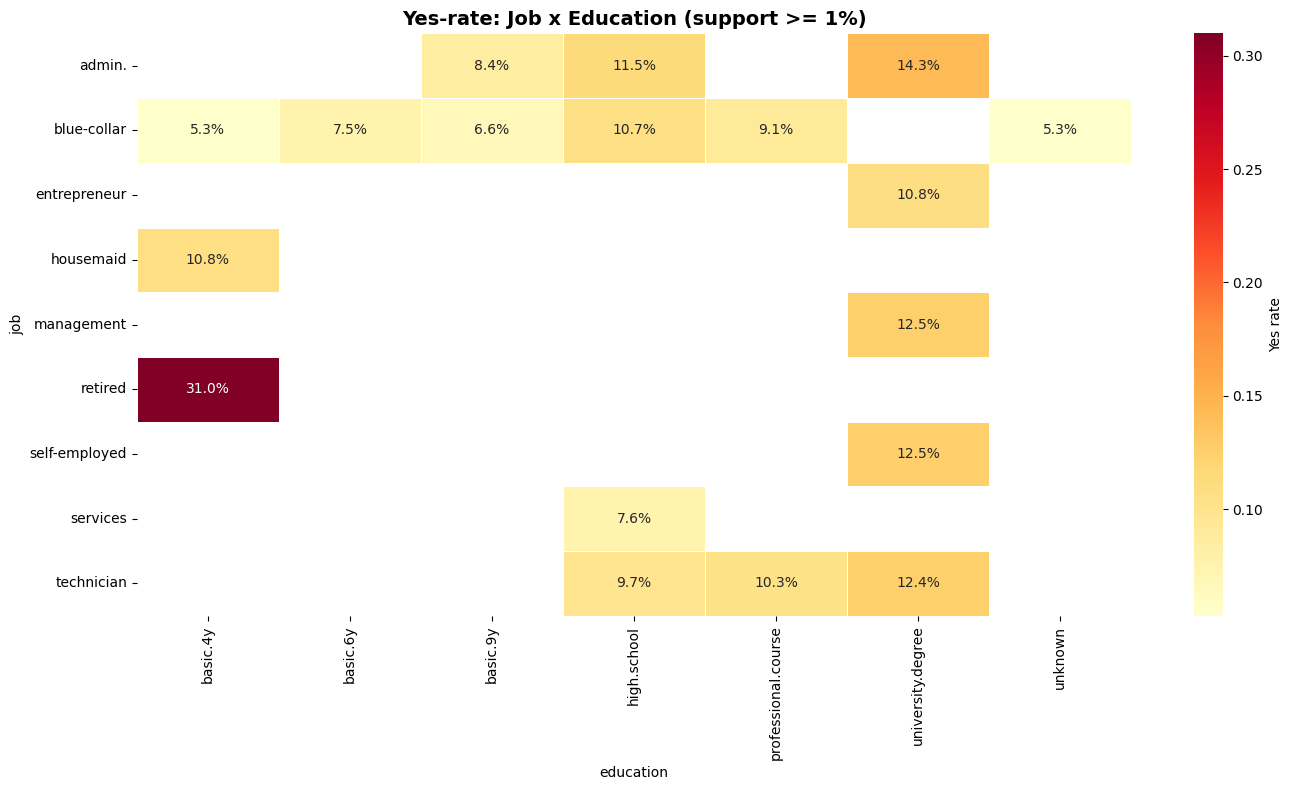

In [6]:
pivot = seg_filtered.pivot_table(index="job", columns="education",
                                 values="yes_rate", aggfunc="mean")

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Yes rate"})
ax.set_title("Yes-rate: Job x Education (support >= 1%)",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/06_segment_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.2 Segment theo Month x Contact

In [7]:
seg_mc = df.groupby(["month", "contact"]).agg(
    total=("y", "count"),
    n_yes=("y", lambda x: (x == "yes").sum()),
).reset_index()
seg_mc["yes_rate"] = seg_mc["n_yes"] / seg_mc["total"]
seg_mc["support_pct"] = seg_mc["total"] / len(df) * 100
seg_mc["lift"] = seg_mc["yes_rate"] / baseline_rate

seg_mc_f = seg_mc[seg_mc["support_pct"] >= 1.0].sort_values("lift", ascending=False)

print("TOP SEGMENTS: month x contact (support >= 1%):")
print(f"{'Month':<10s} {'Contact':<12s} {'Total':>7s} {'Yes':>5s} {'Rate':>8s} {'Lift':>6s}")
print("-" * 55)
for _, row in seg_mc_f.head(10).iterrows():
    print(f"{row['month']:<10s} {row['contact']:<12s} {row['total']:>7d} {row['n_yes']:>5d} "
          f"{row['yes_rate']:>8.2%} {row['lift']:>6.2f}")

TOP SEGMENTS: month x contact (support >= 1%):
Month      Contact        Total   Yes     Rate   Lift
-------------------------------------------------------
mar        cellular         486   252   51.85%   4.60
sep        cellular         482   238   49.38%   4.38
oct        cellular         563   253   44.94%   3.99
jun        cellular         820   349   42.56%   3.78
apr        cellular        2444   493   20.17%   1.79
nov        telephone        425    50   11.76%   1.04
may        cellular        5517   614   11.13%   0.99
aug        cellular        5907   619   10.48%   0.93
nov        cellular        3675   366    9.96%   0.88
jul        cellular        6092   590    9.68%   0.86


### 4.3 Giải thích: Tại sao tháng 3, 9, 10 có yes-rate cao?

> Theo nghiên cứu gốc (Moro et al., 2014) và context kinh tế Bồ Đào Nha 2008-2013:

1. **Tháng 3, 9, 10** là thời điểm ngân hàng chạy chiến dịch **tập trung với số lượng cuộc gọi ít hơn** (486-563 cuộc so với 5000-6000 cuộc vào tháng 5, 7, 8). Khi gọi ít hơn, ngân hàng **chọn lọc khách hàng kỹ hơn** → tỷ lệ thành công cao hơn.

2. **Tháng 5, 7, 8** là thời điểm gọi **đại trà** (mass campaign) → nhiều cuộc gọi nhưng ít chọn lọc → tỷ lệ thấp.

3. **Cellular vs Telephone**: Khách dùng cellular có yes-rate cao hơn telephone — có thể do nhóm này trẻ hơn, thu nhập cao hơn, hoặc đơn giản là dễ tiếp cận hơn.

> ⚠️ Đây là **giải thích dựa trên context**, KHÔNG phải quan hệ nhân quả đã chứng minh.
> Gọi vào tháng 3 không đảm bảo khách sẽ đăng ký — tỷ lệ cao có thể do selection bias trong chiến dịch.

## 5. Duration Impact Analysis

In [8]:
print("=" * 70)
print("  TÁC ĐỘNG DURATION")
print("=" * 70)

print("\nTop 5 Features - Scenario A:")
imp_A = res_scratch["scenario_A"]["feature_importance"]
names_A = res_scratch["scenario_A"]["feature_names"]
for i in np.argsort(imp_A)[::-1][:5]:
    print(f"  {names_A[i]}: {imp_A[i]:.4f}")

print("\nTop 5 Features - Scenario B:")
imp_B = res_scratch["scenario_B"]["feature_importance"]
names_B = res_scratch["scenario_B"]["feature_names"]
for i in np.argsort(imp_B)[::-1][:5]:
    print(f"  {names_B[i]}: {imp_B[i]:.4f}")

print("\nPHÂN TÍCH:")
print("  - Duration không phù hợp cho dự đoán trước chiến dịch")
print("  - Duration có giá trị cho phân tích hậu nghiệm")
print("  - Khi loại duration, chỉ số kinh tế vĩ mô và lịch sử tiếp thị nổi lên")

  TÁC ĐỘNG DURATION

Top 5 Features - Scenario A:
  duration: 0.5094
  nr.employed: 0.3525
  pdays: 0.0445
  euribor3m: 0.0357
  cons.conf.idx: 0.0318

Top 5 Features - Scenario B:
  nr.employed: 0.6422
  pdays: 0.1359
  cons.conf.idx: 0.0611
  euribor3m: 0.0468
  month_oct: 0.0222

PHÂN TÍCH:
  - Duration không phù hợp cho dự đoán trước chiến dịch
  - Duration có giá trị cho phân tích hậu nghiệm
  - Khi loại duration, chỉ số kinh tế vĩ mô và lịch sử tiếp thị nổi lên


## 6. Tổng kết Data-Centric Mining

> **Câu hỏi cốt lõi:** Tại sao chọn hướng Data-Centric thay vì Model-Centric?
>
> **Model-Centric**: Thử nhiều model (DT, RF, SVM, XGBoost...) → chọn model accuracy cao nhất.
> **Data-Centric**: Giữ 1 model (DT), thay đổi DATA → đo tác động → rút tri thức.

In [9]:
print("=" * 75)
print("  DATA-CENTRIC vs MODEL-CENTRIC")
print("=" * 75)
print()
print("Model-Centric (cách tiếp cận phổ biến):")
print("  - Thử nhiều model, chọn model tốt nhất")
print("  - Tập trung vào accuracy/F1 cao nhất")
print("  - Kết luận: 'XGBoost đạt 95% accuracy'")
print("  - Hạn chế: nếu chỉ chọn metric cao nhất, phần giải thích dữ liệu có thể bị xem nhẹ")
print()
print("Data-Centric (cách tiếp cận của dự án này):")
print("  - Giữ 1 model (Decision Tree), thay đổi DATA")
print("  - Tập trung vào: dữ liệu nào ảnh hưởng kết quả?")
print("  - Kết luận: 'Duration tăng F1 từ 0.37 lên 0.57'")
print("  -           'Undersampling tăng Recall +0.33 nhưng giảm Precision -0.20'")
print("  -           'nr.employed là feature quan trọng nhất khi không có duration'")
print("  - Giá trị: HIỂU được đặc điểm dữ liệu, rút ra TRI THỨC")
print()
print("-" * 75)
print()
print("CHỨNG MINH BẰNG ABLATION (NB02):")
print()
print("  Thay đổi DATA (giữ nguyên model DT, gini, depth=5):")
print("    A → B (loại duration):    F1 giảm 0.57 -> 0.37  (delta = -0.20)")
print("    B → B+ (undersampling):   Recall tăng 0.26 -> 0.59 (delta = +0.33)")
print()
print("  -> Thay đổi DATA tạo ra chênh lệch F1 = 0.20")
print("     Đây là mức chênh lệch đủ lớn để cho thấy transformation dữ liệu ảnh hưởng đáng kể")
print("     Trong phạm vi project này, chỉ thay đổi dữ liệu đã tạo ra khác biệt rõ ràng")
print()
print("KẾT LUẬN:")
print("  1. Trong phạm vi project này, thay đổi dữ liệu tạo ra khác biệt lớn về metric")
print("  2. Hiểu dữ liệu (duration, imbalance) giúp quyết định đúng hơn")
print("  3. Decision Tree đủ để rút tri thức (rules, segments, importance)")
print("  4. Với mục tiêu giải thích và rút tri thức, Decision Tree là lựa chọn phù hợp")

  DATA-CENTRIC vs MODEL-CENTRIC

Model-Centric (cách tiếp cận phổ biến):
  - Thử nhiều model, chọn model tốt nhất
  - Tập trung vào accuracy/F1 cao nhất
  - Kết luận: 'XGBoost đạt 95% accuracy'
  - Hạn chế: nếu chỉ chọn metric cao nhất, phần giải thích dữ liệu có thể bị xem nhẹ

Data-Centric (cách tiếp cận của dự án này):
  - Giữ 1 model (Decision Tree), thay đổi DATA
  - Tập trung vào: dữ liệu nào ảnh hưởng kết quả?
  - Kết luận: 'Duration tăng F1 từ 0.37 lên 0.57'
  -           'Undersampling tăng Recall +0.33 nhưng giảm Precision -0.20'
  -           'nr.employed là feature quan trọng nhất khi không có duration'
  - Giá trị: HIỂU được đặc điểm dữ liệu, rút ra TRI THỨC

---------------------------------------------------------------------------

CHỨNG MINH BẰNG ABLATION (NB02):

  Thay đổi DATA (giữ nguyên model DT, gini, depth=5):
    A → B (loại duration):    F1 giảm 0.57 -> 0.37  (delta = -0.20)
    B → B+ (undersampling):   Recall tăng 0.26 -> 0.59 (delta = +0.33)

  -> Thay đổi 

### 6.1 Imbalance Strategy

> Dataset mất cân bằng mạnh, nên không đánh giá bằng accuracy đơn thuần. Chiến lược của dự án là dùng stratified split/CV, metric phù hợp cho class `yes`, và dùng undersampling như ablation để phân tích trade-off.


In [10]:
print("=" * 75)
print("  IMBALANCE STRATEGY")
print("=" * 75)
print()
print("BỐI CẢNH:")
print("  - Dataset mất cân bằng mạnh: ~89% no / ~11% yes")
print("  - Majority baseline dự đoán toàn 'no' đã đạt Accuracy = 88.7%")
print("  - Vì vậy accuracy đơn thuần có thể gây hiểu nhầm")
print()
print("CHIẾN LƯỢC CỦA DỰ ÁN:")
print("  1. Dùng stratified train/test split để giữ tỷ lệ yes/no ổn định")
print("  2. Dùng 5-fold Stratified CV để đánh giá ổn định hơn")
print("  3. Đánh giá bằng Precision, Recall, F1 cho class yes")
print("  4. Không dùng SMOTE vì dữ liệu one-hot; SMOTE có thể tạo giá trị không có ý nghĩa")
print("  5. Undersampling chỉ dùng như ablation, không phải scenario chính")
print()
print("TRADE-OFF QUAN SÁT ĐƯỢC (Scenario B, no duration):")
print("  - Baseline:       Precision=0.65, Recall=0.26, F1=0.37")
print("  - Undersampling:  Precision=0.45, Recall=0.59, F1=0.51")
print("  - Recall tăng mạnh nhưng Precision giảm -> phụ thuộc mục tiêu kinh doanh")
print()
print("KẾT LUẬN:")
print("  - Nếu muốn tiết kiệm chi phí gọi: ưu tiên Precision cao")
print("  - Nếu muốn không bỏ sót khách tiềm năng: ưu tiên Recall cao")
print("  - Project không chỉ báo accuracy, mà phân tích đúng trade-off của class imbalance")


  IMBALANCE STRATEGY

BỐI CẢNH:
  - Dataset mất cân bằng mạnh: ~89% no / ~11% yes
  - Majority baseline dự đoán toàn 'no' đã đạt Accuracy = 88.7%
  - Vì vậy accuracy đơn thuần có thể gây hiểu nhầm

CHIẾN LƯỢC CỦA DỰ ÁN:
  1. Dùng stratified train/test split để giữ tỷ lệ yes/no ổn định
  2. Dùng 5-fold Stratified CV để đánh giá ổn định hơn
  3. Đánh giá bằng Precision, Recall, F1 cho class yes
  4. Không dùng SMOTE vì dữ liệu one-hot; SMOTE có thể tạo giá trị không có ý nghĩa
  5. Undersampling chỉ dùng như ablation, không phải scenario chính

TRADE-OFF QUAN SÁT ĐƯỢC (Scenario B, no duration):
  - Baseline:       Precision=0.65, Recall=0.26, F1=0.37
  - Undersampling:  Precision=0.45, Recall=0.59, F1=0.51
  - Recall tăng mạnh nhưng Precision giảm -> phụ thuộc mục tiêu kinh doanh

KẾT LUẬN:
  - Nếu muốn tiết kiệm chi phí gọi: ưu tiên Precision cao
  - Nếu muốn không bỏ sót khách tiềm năng: ưu tiên Recall cao
  - Project không chỉ báo accuracy, mà phân tích đúng trade-off của class imbala

## 7. Kết luận + Khuyến nghị

> Kết luận **trung thực, có điều kiện**, không nói quá.

In [11]:
print("=" * 70)
print("  KẾT LUẬN TỔNG HỢP")
print("=" * 70)
print()
print("1. VỀ THUẬT TOÁN:")
print("   - DT from scratch cho kết quả gần tương đương sklearn")
print("   - Sai khác nhỏ (nếu có): tie-breaking, threshold, implementation")
print("   - Gini max_depth=5: cân bằng accuracy và interpretability")
print()
print("2. VỀ DỮ LIỆU:")
print("   - Duration tăng metric nhưng prediction-time unavailable")
print("   - Class imbalance (89:11): accuracy đơn thuần không đủ")
print("   - Metric phù hợp: F1, Recall cho class yes")
print()
print("3. KHUYẾN NGHỊ (pattern quan sát, KHÔNG phải nhân quả):")
print("   - poutcome=success có tỷ lệ đăng ký cao -> ưu tiên gọi lại")
print("   - Tỷ lệ khác nhau theo tháng: cần kiểm chứng thêm")
print("   - Correlation ≠ causation")
print()
print("4. GIỚI HẠN:")
print("   - Chỉ 1 thuật toán (DT)")
print("   - Dataset từ Bồ Đào Nha 2008-2010")
print("   - max_depth=5 chọn thủ công")
print("   - Unknown values giữ nguyên")

  KẾT LUẬN TỔNG HỢP

1. VỀ THUẬT TOÁN:
   - DT from scratch cho kết quả gần tương đương sklearn
   - Sai khác nhỏ (nếu có): tie-breaking, threshold, implementation
   - Gini max_depth=5: cân bằng accuracy và interpretability

2. VỀ DỮ LIỆU:
   - Duration tăng metric nhưng prediction-time unavailable
   - Class imbalance (89:11): accuracy đơn thuần không đủ
   - Metric phù hợp: F1, Recall cho class yes

3. KHUYẾN NGHỊ (pattern quan sát, KHÔNG phải nhân quả):
   - poutcome=success có tỷ lệ đăng ký cao -> ưu tiên gọi lại
   - Tỷ lệ khác nhau theo tháng: cần kiểm chứng thêm
   - Correlation ≠ causation

4. GIỚI HẠN:
   - Chỉ 1 thuật toán (DT)
   - Dataset từ Bồ Đào Nha 2008-2010
   - max_depth=5 chọn thủ công
   - Unknown values giữ nguyên
